In [ ]:
# EJECUCIÓN SECUENCIAL (OPCIONAL)
# Si deseas ejecutar este código seccionado secuencialmente y heredar las variables del archivo anterior, borra el '#' de la siguiente línea de código:

# %run 01_Configuracion_Carga.ipynb

#### **Reescalado de Imagen**

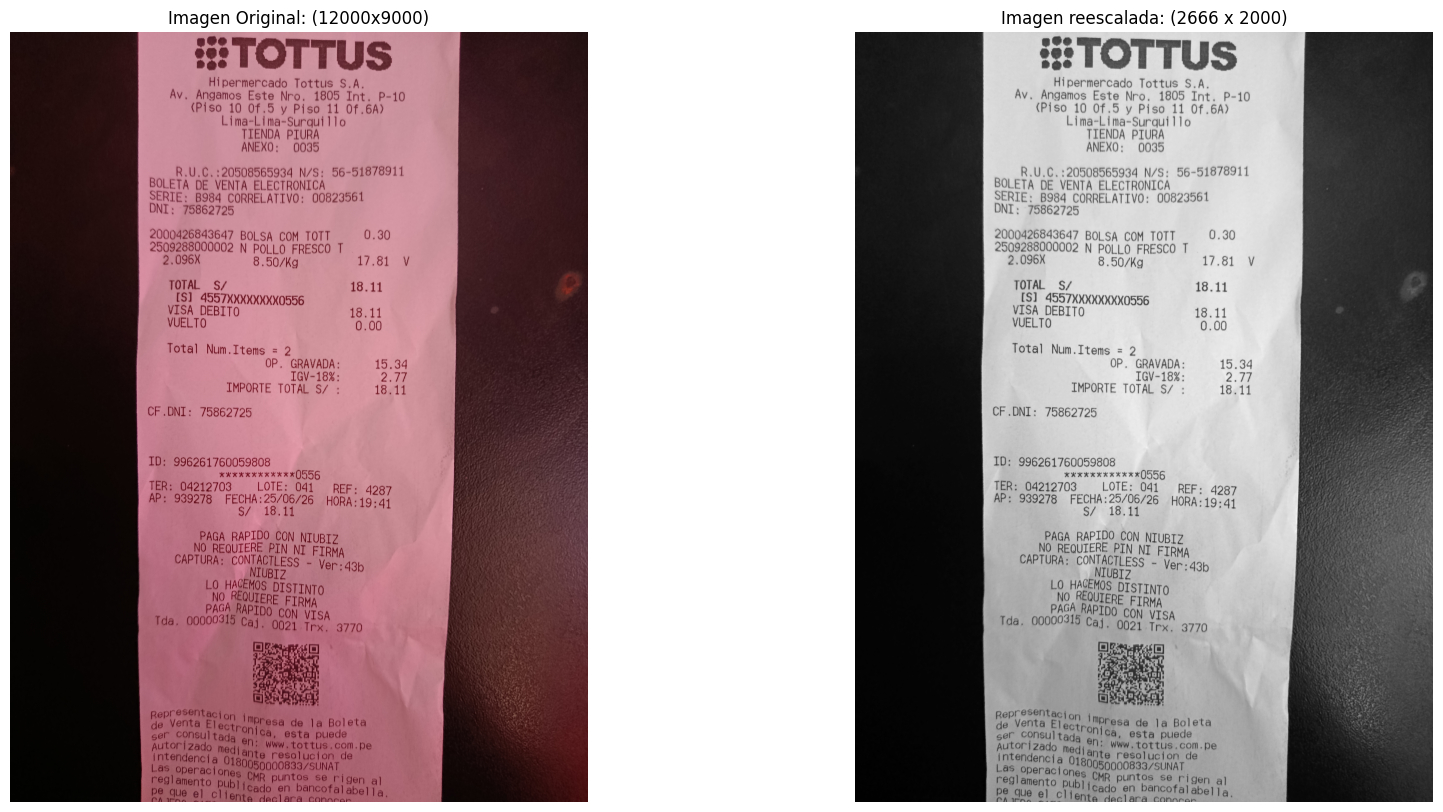

In [ ]:
# REESCALADO Y TRATAMIENTO INICIAL

if img is not None:
    # Calculo de proporciones
    ancho_des = 2000
    rows, cols, chann = img.shape
    rate = ancho_des / float(cols)
    alto_des = int(rows * rate)

    # Selección adaptativa del método de interpolación
    # INTER_AREA para reducir resolución; INTER_CUBIC para ampliar
    interpolacion = cv2.INTER_AREA if cols > ancho_des else cv2.INTER_CUBIC

    # Reescalado y conversión a escala de grises
    img_rees = cv2.resize(img, (ancho_des, alto_des), interpolation=interpolacion)
    imgG = cv2.cvtColor(img_rees, cv2.COLOR_BGR2GRAY)

    # Visualización
    plt.figure(figsize=(20, 10))
    plt.subplot(1, 2, 1)
    plt.title(f"Imagen Original: ({rows}x{cols})")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(f"Imagen reescalada: ({alto_des} x {ancho_des})")
    plt.imshow(imgG, cmap='gray')
    plt.axis('off')
    plt.show()
else:
    print("No hay ninguna imagen cargada en 'img'. Por favor ejecute la carga de su imagen primero.")

#### **Máscara Otsu para Segmentación**

Umbral calculado por Otsu: 89.0
Kernel de cierre: 100x100


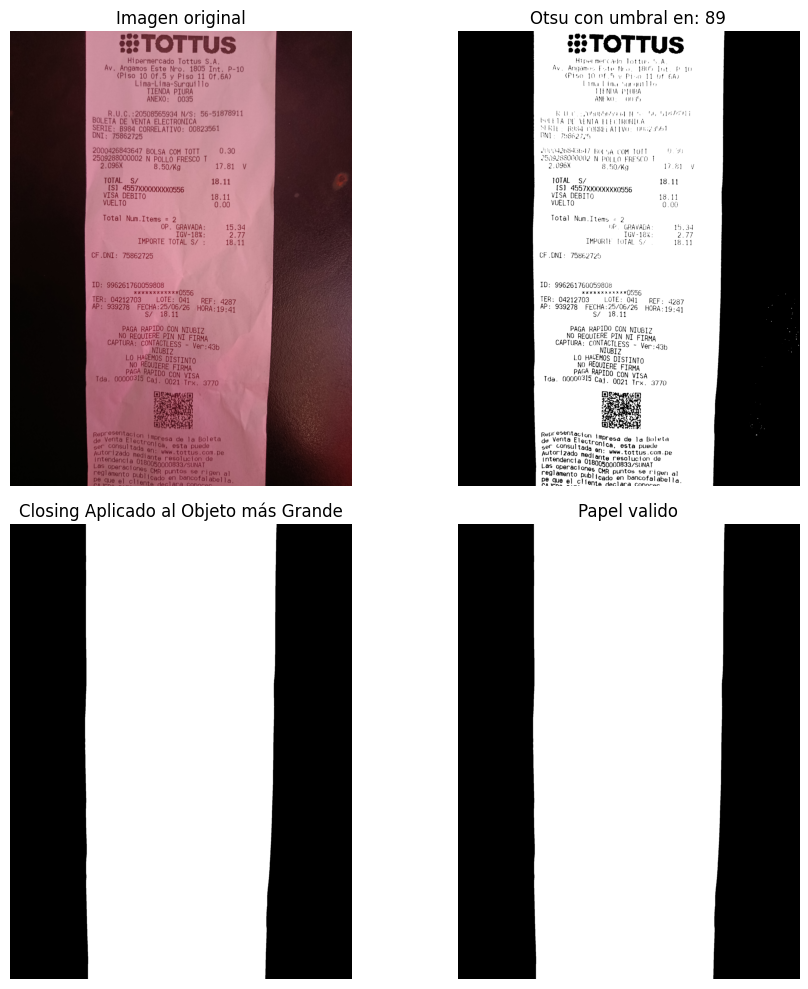

In [ ]:
# OTSU Y RELLENO INTERNO DE LA MÁSCARA

# Suavizado y Umbralización de Otsu
# El suavizado previo reduce ruido y Otsu busca de forma automática el mejor umbral de brillo para binarizar la imagen
k_blur = max(3, (round(ancho_des * 0.0025) | 1))
img_blur_otsu = cv2.GaussianBlur(imgG, (k_blur, k_blur), 0)
umbral_otsu, mascara_otsu = cv2.threshold(img_blur_otsu, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(f"Umbral calculado por Otsu: {umbral_otsu:.1f}")

# Extracción del componente conectado más grande para descartar artefactos más pequeños y aislados
n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mascara_otsu, connectivity=8)

if n_labels > 1:
    idx_mayor = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    mascara_papel = np.uint8(labels == idx_mayor) * 255
else:
    mascara_papel = mascara_otsu.copy()

# Cierre morfológico para cerrar grietas del borde que podrían dejar el contorno fragmentado
k_closing = max(5, round(ancho_des * 0.05))

print(f"Kernel de cierre: {k_closing}x{k_closing}")

kernel_closing = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k_closing, k_closing))
mascara_papel = cv2.morphologyEx(mascara_papel, cv2.MORPH_CLOSE, kernel_closing, iterations=1)

#  Relleno interno que toma el contorno EXTERIOR del papel ya tratado, y se rellena por completo hacia adentro.
contornos, _ = cv2.findContours(mascara_papel, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contornos:
    contorno_mayor = max(contornos, key=cv2.contourArea)
    mascara_papel_final = np.zeros_like(mascara_papel)
    cv2.drawContours(mascara_papel_final, [contorno_mayor], -1, 255, thickness=cv2.FILLED)
else:
    print("No se detectaron contornos válidos tras Otsu.")
    mascara_papel_final = mascara_papel.copy()

plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.title("Imagen original")
plt.imshow(cv2.cvtColor(img_rees, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title(f"Otsu con umbral en: {umbral_otsu:.0f}")
plt.imshow(mascara_otsu, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title(f"Closing Aplicado al Objeto más Grande")
plt.imshow(mascara_papel, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title(f"Papel valido")
plt.imshow(mascara_papel_final, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()